# Generating Time-Optimal Trajectories

This notebook shows how to generate time-optimal trajectories in RobotBlockSet. The goal is to start from a predefined geometric path and compute a time-parameterized trajectory that respects velocity and acceleration limits while minimizing execution time.


## Workflow overview

The examples below follow the standard workflow for time-optimal trajectory generation: define a robot model, construct a geometric path, specify path or joint constraints, build the path kinematics, solve the time-optimal parameterization, and finally visualize the resulting path-space, Cartesian, and joint trajectories.

Use this notebook as a practical reference when you want to understand the available API or adapt the same procedure to a different robot or path.


# Imports

In [1]:
import numpy as np
import scipy.io
from robotblockset.optimal import *

# Use compact numeric printing to make trajectory arrays easier to inspect.
np.set_printoptions(formatter={"float": "{: 0.4f}".format})

from robotblockset.trajectories import cline, gradientPath, gradientCartesianPath, uniqueCartesianPath
from robotblockset.tools import rbs_type
from robotblockset.transformations import map_pose, rot_z

from robotblockset.graphics import plotcpath, plotctraj, plotjtraj

from robotblockset.robots import robot
from robotblockset.robot_spec import panda_spec


# Define robot

In [2]:
# Define a lightweight Panda robot model without attaching a simulator scene.
class panda_test(panda_spec):
    def __init__(self):
        panda_spec.__init__(self)
        robot.__init__(self)
        self.Init()

    def __del__(self):
        self.Message("Robot deleted", 2)
r = panda_test()

# Set the tool center point used for kinematics and trajectory evaluation.
TCP = map_pose(Q=rot_z(-np.pi/4), p=[0, 0, 0.1034])
r.SetTCP(TCP, frame='Flange')
dkin = r.Kinmodel
print(r.q_home)
print(r.TCP)


[ 0.0000 -0.7854  0.0000 -2.3562  0.0000  1.5708  0.7854]
[[ 0.7071  0.7071  0.0000  0.0000]
 [-0.7071  0.7071  0.0000  0.0000]
 [ 0.0000  0.0000  1.0000  0.1034]
 [ 0.0000  0.0000  0.0000  1.0000]]


# Time-Optimal Trajectory

In **time-optimal parameterization**, the trajectory is calculated to minimize the time required to follow a given path while adhering to velocity and acceleration constraints. Ideally, joint torque limits should also be considered, but this requires a dynamic model of the robot. If the dynamic model is unavailable, estimated maximum accelerations can still be used to obtain a practical solution.


## Define path

The process starts by defining a geometric path. A path defined as a sequence of consecutive points can generally be expressed as a parametric curve
\begin{aligned}
\mathbf{x} &= \mathbf{f}(s)\\
\mathbf{v}_p &= \mathbf{J}_s \dot s \\n
\mathbf{\dot v}_p &= \mathbf{J}_s \ddot s + \mathbf{J}_s^\prime \dot s^2
\end{aligned}
where $\mathbf{f}(\cdot)$ is a vector function and $s$ is the path parameter, with $s \in [s_0, s_1]$.


In [3]:
# Define two Cartesian waypoints as position + orientation increments.
points6d = np.array(
    [
        [0.2, 0.0, 0.0, 0, 0, 0],
        [0.0, -0.2, -0.2, 0, 0, 0],
    ]
)
points6d_init = [0.3, 0, 0.5, 0, 0, np.pi]
for i in range(points6d.shape[0]):
    points6d[i, :] = points6d[i, :] + points6d_init
points = prpy2x(points6d)

# Sample a straight Cartesian path and map it to joint space with inverse kinematics.
tsamp = 0.01
tt = np.arange(0, 1 + tsamp, tsamp)
path_x = cline(points[0, :], points[1, :], tt)[0]
path_q, _err = r.IKinPath(path_x, r.q_home)


The constraints that must be respected during trajectory generation are defined as
\begin{aligned} 
\|\mathbf{v}_p\| &\le \|\mathbf{v}_p\|_{\max} \\ 
\|\mathbf{v}_{pd}\| &\le \|\mathbf{v}_{pd}\|_{\max} \\ 
|\mathbf{v}_{p,i}| &\le \mathbf{v}_{p,\max,i}, \quad i=1,\ldots,6 \\ 
|\mathbf{v}_{pd,i}| &\le \mathbf{v}_{pd,\max,i}, \quad i=1,\ldots,6 \\ 
|\mathbf{\dot q}_j| &\le \mathbf{\dot q}_{\max,j}, \quad j=1,\ldots,n \\ 
|\mathbf{\ddot q}_j| &\le \mathbf{\ddot q}_{\max,j}, \quad j=1,\ldots,n 
\end{aligned}
The goal is to find a feasible trajectory, either in the operational space ($\mathbf{x}(t)$, $\mathbf{v}_p(t)$, $\mathbf{\dot v}_p(t)$) or in the joint space ($\mathbf{q}(t)$, $\mathbf{\dot q}(t)$, $\mathbf{\ddot q}(t)$).

RBS provides class `path_constraints`, which stores the velocity and acceleration limits used during time-optimal trajectory generation. The constructor does not take any arguments; instead, limits are assigned to its attributes after the object is created.

| Argument / Attribute | Description |
| --- | --- |
| Constructor arguments | None. Create the object with `path_constraints()` and then fill in the limits you want to enforce. |
| `xdnmax` | Maximum scalar path velocity in Cartesian space. |
| `xddnmax` | Maximum scalar path acceleration in Cartesian space. |
| `xdmax` | Per-component Cartesian velocity limits, typically a 6D vector. |
| `xddmax` | Per-component Cartesian acceleration limits, typically a 6D vector. |
| `qdmax` | Per-joint velocity limits. |
| `qddmax` | Per-joint acceleration limits. |

In [4]:
# Create the constraint container and populate the active limits.
path_con = path_constraints()
# path_con.xdnmax = 1
# path_con.xddnmax = 2
# path_con.xdmax = np.ones(6) * 1
# path_con.xddmax = np.ones(6) * 5
path_con.qdmax = np.ones(7) * 1
path_con.qddmax = np.ones(7) * 2


We convert all constraints into limits on $\dot sd$ and $\ddot s$, where $s$ is the path parameter. The path is then given as
\begin{aligned} 
	\mathbf{\dot q} &= \mathbf{J}^\ddagger \mathbf{J}_s \dot s\\
	\mathbf{\ddot q} &= \mathbf{J}^\ddagger (\mathbf{J}_s \ddot s + \mathbf{J}_s^\prime \dot s^2 - \mathbf{\dot J} \mathbf{\dot q})
\end{aligned} 
where $\mathbf{J}^\ddagger$ is the generalized inverse of the Jacobian matrix $\mathbf{J}$.

The calculation of the optimal trajectory can be done for Cartesian or joint path.

RBS provides class `path_kinematics`, which builds the path model used by the optimizer. It stores the path parameterization and computes the path derivatives needed to convert limits on motion into bounds on `\dot{s}` and `\ddot{s}`.

| Argument | Description |
| --- | --- |
| `path` | Array of path samples. This is the Cartesian path or joint path that will be parameterized. |
| `path_s` | Optional array of path-parameter values associated with the samples in `path`. If omitted, it is computed from the path length. |
| `path_q` | Optional joint-space samples corresponding to the path. Useful when the main path is Cartesian and joint values are also available. |
| `Cartesian` | If `True`, treats `path` as a Cartesian path; otherwise it is treated as a joint-space path. |
| `dkin` | Optional forward-kinematics callable used when Cartesian quantities and Jacobians must be evaluated from joint values. |
| `ds` | Small path step used for numerical differentiation. Default: `0.001`. |
| `scale` | SE(3) norm scale factor(s) used when computing path length for Cartesian poses. Default: `(1.0, 1.0)`. |

In [5]:
# Build the path model used by the optimizer, either in Cartesian or joint form.
scale = [1, 1]
Cartesian = False
if Cartesian:
    path_kin = path_kinematics(path_x, path_q=path_q, dkin=dkin, Cartesian=True, scale=scale)
else:
    path_kin = path_kinematics(path_q, dkin=dkin, Cartesian=False, scale=scale)


All constraints are then converted into limits in path space, which yields the admissible velocity bounds along the path.


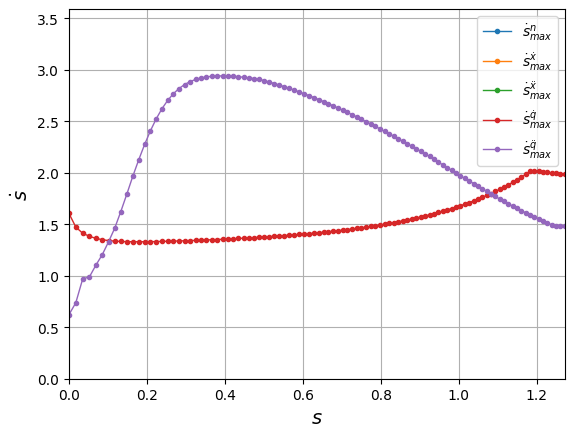

In [6]:
# Visualize the admissible path-velocity bounds implied by the constraints.
sd_bounds = plot_path_bounds(path_kin, path_con)


## Generate time-optimal trajectory

To find a time-optimal trajectory, an optimization approach must be used. Among various possible objective functions, this notebook uses execution time minimization subject to the path-dependent bounds derived above.


To calculated time-optimal trajectory RBS provides function `timeopttraj` with arguments:

| Argument | Description |
| --- | --- |
| `path_kin` | `path_kinematics` object describing the path geometry and derivatives used during optimization. |
| `path_con` | `path_constraints` object with the velocity and acceleration limits in Cartesian and/or joint space. |
| `s0` | Initial value of the path parameter `s`. Default: `0`. |
| `send` | Final value of the path parameter. If `None`, the function uses the last value in `path_kin.path_s`. |
| `sd0` | Initial path velocity `\dot{s}`. Default: `0`. |
| `sdend` | Final path velocity `\dot{s}`. Default: `0`. |
| `tsamp` | Sampling period used for integrating and returning the trajectory. Default: `0.01`. |
| `plot` | If `True`, plots the feasible `s`-`\dot{s}` region and the forward/backward integration steps. Default: `False`. |
| `sd_bounds` | Optional precomputed path-velocity bounds for plotting. If omitted and `plot=True`, they are computed internally. |

In [7]:
# Solve the time-optimal parameterization along the predefined path.
T, sp, sv, sa = timeopttraj(path_kin, path_con, tsamp=0.01)


The generated trajectory is transformed from path space back to Cartesian space or joint space for visualization and further use.


In [8]:
# Convert the path-space solution back to Cartesian and joint trajectories.
if Cartesian:
    path_rx, path_rxd, path_rxdd = path_kin.s2x(sp, sv, sa)
    path_rq, path_rqd, path_rqdd = path_kin.s2q_x(sp, sv, sa)
else:
    path_rq, path_rqd, path_rqdd = path_kin.s2x(sp, sv, sa)
    n = path_rq.shape[0]
    path_rx = np.zeros((n, 7))
    for i in range(n):
        path_rx[i, :] = dkin(path_rq[i, :])[0]
    path_rx = uniqueCartesianPath(path_rx)
    path_rxd = gradientCartesianPath(path_rx, T)
    path_rxdd = gradientPath(path_rxd, T)


The trajectories in path space are


Text(0, 0.5, '$\\ddot s$')

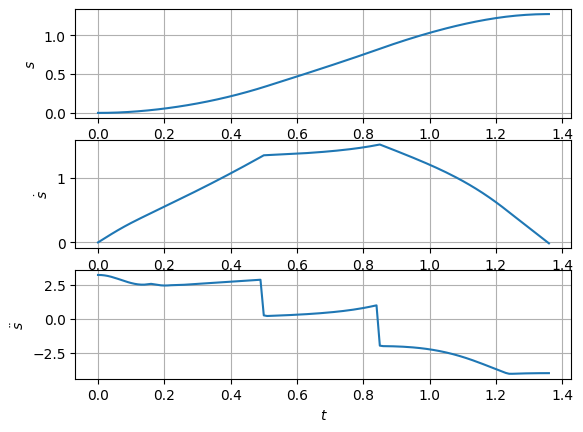

In [9]:
# Plot the optimized path parameter, path velocity, and path acceleration.
_, ax = plotjtraj(T, sp, sv, sa, fig_num="Time optimal path trajectory")
ax[0].set_ylabel("$s$")
ax[1].set_ylabel("$\dot s$")
ax[2].set_ylabel("$\ddot s$")


The trajectories in task space are

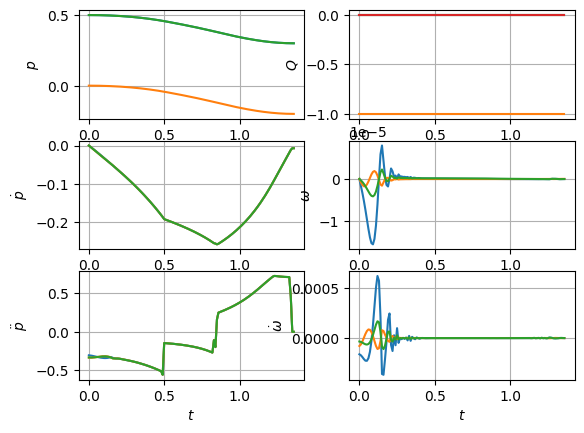

In [10]:
# Plot the resulting Cartesian trajectory.
_ = plotctraj(T, path_rx, fig_num="Time optimal task trajectory")


The trajectories in joint space are


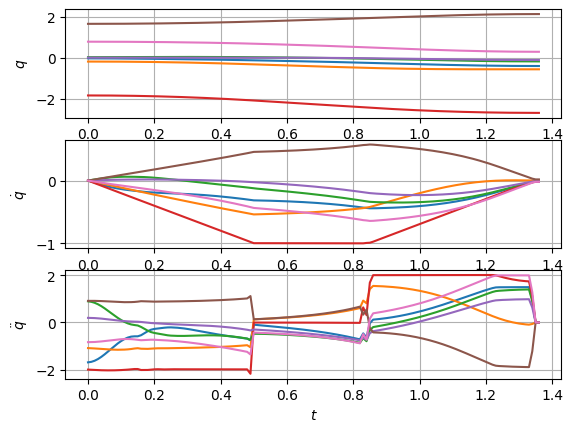

In [11]:
# Plot the resulting joint-space trajectory.
_ = plotjtraj(T, path_rq, fig_num="Time optimal joint trajectory")


For the joint path, the optimal trajectory can be calculated using function `timeopt_joint_traj` with arguments:

| Argument | Description |
| --- | --- |
| `path_q` | Array of joint-space waypoints with shape `(n, nj)` defining the path to parameterize. |
| `path_con` | `path_constraints` object with the velocity and acceleration limits used by the optimizer. |
| `dkin` | Optional forward-kinematics callable used when Cartesian constraints need to be evaluated from the joint path. |
| `scale` | SE(3) norm scale factor(s) used inside the path kinematics model. Default: `(1.0, 1.0)`. |
| `s0` | Initial value of the path parameter `s`. Default: `0`. |
| `send` | Final value of the path parameter. If `None`, the last path sample is used. |
| `sd0` | Initial path velocity `\dot{s}`. Default: `0`. |
| `sdend` | Final path velocity `\dot{s}`. Default: `0`. |
| `tsamp` | Sampling period of the generated optimal trajectory. Default: `0.01`. |
| `plot` | If `True`, enables the same diagnostic plot as `timeopttraj`. Default: `False`. |
| `sd_bounds` | Optional precomputed path-velocity bounds passed through to `timeopttraj` when plotting. |

> ⚠️**Note:** If no direct kinematics is defined (argument `dkin`), then task space constraints are not considered.

## Direct joint-space formulation

For a path already represented directly in joint space, RobotBlockSet also provides a higher-level helper that computes a time-optimal joint trajectory without explicitly constructing the intermediate path-space objects shown above.


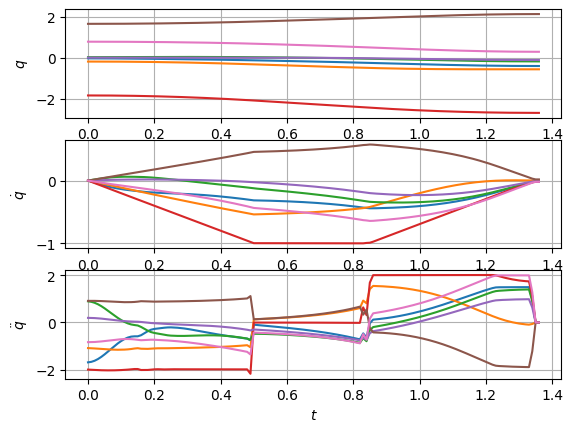

In [12]:
# Compute a time-optimal trajectory directly from the sampled joint path.
T, rqt, rqdt, rqddt = timeopt_joint_traj(path_q, path_con)

_ = plotjtraj(T, rqt, fig_num="Time optimal joint trajectory 1")
